<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
1. Objetivo do EDA
</h2>

O objetivo desta análise exploratória é entender:

- a estrutura e a qualidade dos dados  
- o comportamento das principais variáveis  
- quais fatores parecem influenciar o NPS  

Esta etapa segue uma lógica próxima ao método científico: observar, levantar hipóteses e validar padrões.

O foco aqui não é modelagem, mas gerar entendimento suficiente para orientar as próximas etapas do projeto.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../data/raw/desafio_nps_fase_1.csv")

df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
2. Estrutura dos dados
</h2>

Nesta etapa, o objetivo é entender como os dados estão organizados e identificar possíveis problemas iniciais.

Vamos analisar:

- número de linhas e colunas  
- tipos de variáveis  
- possíveis inconsistências  

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   str    
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64  
 14  res

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000


### Observações iniciais

- A base possui 2.500 registros e 19 variáveis  
- A variável target é `nps_score`  
- Existem variáveis relacionadas a:
  - logística  
  - atendimento  
  - características do pedido  

Hipótese inicial:

O NPS pode ser influenciado principalmente por fatores ligados à entrega e ao atendimento.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
3. Qualidade dos dados
</h2>

Antes de avançar na análise, faz sentido avaliar a qualidade dos dados.

Nesta etapa, o foco é identificar:

- valores ausentes  
- possíveis duplicidades  
- inconsistências ou valores fora do padrão  

Esse diagnóstico ajuda a entender o nível de confiabilidade da base e a evitar conclusões enviesadas nas etapas seguintes.

In [6]:
df.isnull().sum().sort_values(ascending=False)

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

### Observações

- Não há variáveis com dados faltantes  
- Não foram identificados registros duplicados  

Isso indica que a base está consistente do ponto de vista estrutural, permitindo avançar na análise sem necessidade de tratamento inicial.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
4. Análise da variável alvo (NPS)
</h2>

Antes de analisar os fatores explicativos, faz sentido entender o comportamento da variável alvo.

Nesta etapa, o objetivo é avaliar:

- a distribuição do `nps_score`  
- possíveis concentrações ou assimetrias  
- o equilíbrio entre diferentes níveis de satisfação  

Essa análise ajuda a identificar padrões iniciais e possíveis desafios para as etapas seguintes, como desbalanceamento entre classes.

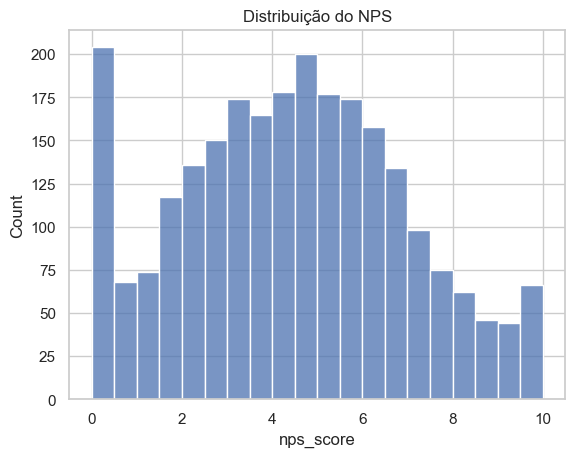

In [8]:
plt.figure()
sns.histplot(df['nps_score'], bins=20)
plt.title("Distribuição do NPS")
plt.show()

<h4 style="color:#2E86C1;">
Análise da variável alvo (NPS)
</h4>

A distribuição do NPS apresenta um comportamento relativamente disperso ao longo da escala de 0 a 10, com maior concentração na faixa intermediária (entre 3 e 7).

Observa-se:

- presença relevante de notas baixas (0–2), indicando um grupo significativo de clientes insatisfeitos (detratores)  
- concentração em notas médias (4–6), sugerindo uma base considerável de clientes neutros  
- menor frequência de notas altas (9–10), indicando uma proporção mais limitada de promotores  

Esse padrão sugere que a experiência do cliente não é consistente, com variação relevante na percepção de valor entregue.

<h4 style="color:#2E86C1;">
Interpretação de negócio
</h4>

- a presença de muitos detratores pode indicar falhas operacionais ou de experiência, como atraso, atendimento ou problemas no pedido  
- a concentração de neutros sugere uma oportunidade clara de melhoria, já que são clientes que podem ser convertidos em promotores  
- a menor quantidade de promotores indica que a empresa ainda não está gerando um nível consistente de encantamento  

<h4 style="color:#2E86C1;">
Hipótese inicial
</h4>

O NPS pode estar sendo impactado por fatores operacionais, principalmente ligados à logística e ao atendimento, que geram experiências inconsistentes ao longo da jornada do cliente.

<Axes: xlabel='nps_score'>

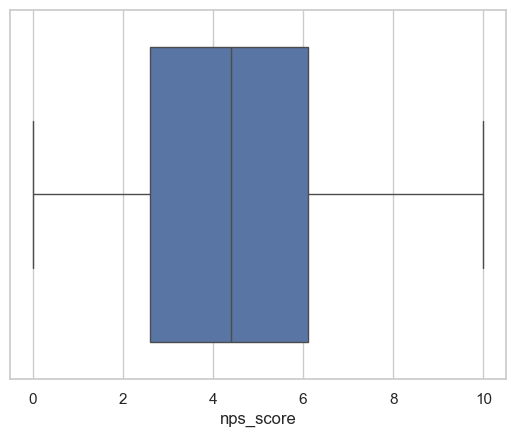

In [9]:
sns.boxplot(x=df['nps_score'])

<h4 style="color:#2E86C1;">
Análise da variável alvo (Boxplot do NPS)
</h4>

O boxplot do NPS reforça a análise anterior, evidenciando a dispersão dos dados e a posição central das avaliações.

Observa-se:

- mediana do NPS localizada aproximadamente entre 4 e 5, indicando que a experiência média do cliente está abaixo da zona de promotores  
- ampla dispersão dos dados, com valores variando de 0 a 10  
- intervalo interquartil (IQR) concentrado aproximadamente entre 3 e 6, mostrando que a maior parte dos clientes está na faixa de neutralidade ou leve insatisfação  
- ausência de forte concentração em valores extremos, reforçando a heterogeneidade da experiência  

<h4 style="color:#2E86C1;">
Interpretação de negócio
</h4>

- a mediana abaixo de 6 sugere que a experiência típica do cliente não é suficiente para gerar recomendação  
- a dispersão elevada indica inconsistência na operação, com clientes tendo experiências bastante diferentes  
- a concentração na faixa intermediária reforça a presença de clientes neutros, que representam uma oportunidade relevante de melhoria  
- a ausência de outliers extremos sugere que o problema não está concentrado em casos isolados, mas distribuído ao longo da base  

<h4 style="color:#2E86C1;">
Hipótese inicial
</h4>

A variabilidade do NPS indica que a experiência do cliente depende fortemente de fatores operacionais, como logística e atendimento, e não de um padrão consistente de qualidade.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
5. Análise univariada (variáveis numéricas)
</h2>

A análise das variáveis numéricas permite entender o comportamento individual de cada atributo antes de avaliar suas relações com o NPS.

Nesta etapa, o foco é observar:

- distribuição dos valores  
- presença de assimetrias  
- possíveis outliers  
- padrões gerais de cada variável  

Esse entendimento é importante para identificar características relevantes da base e orientar as análises bivariadas nas etapas seguintes.

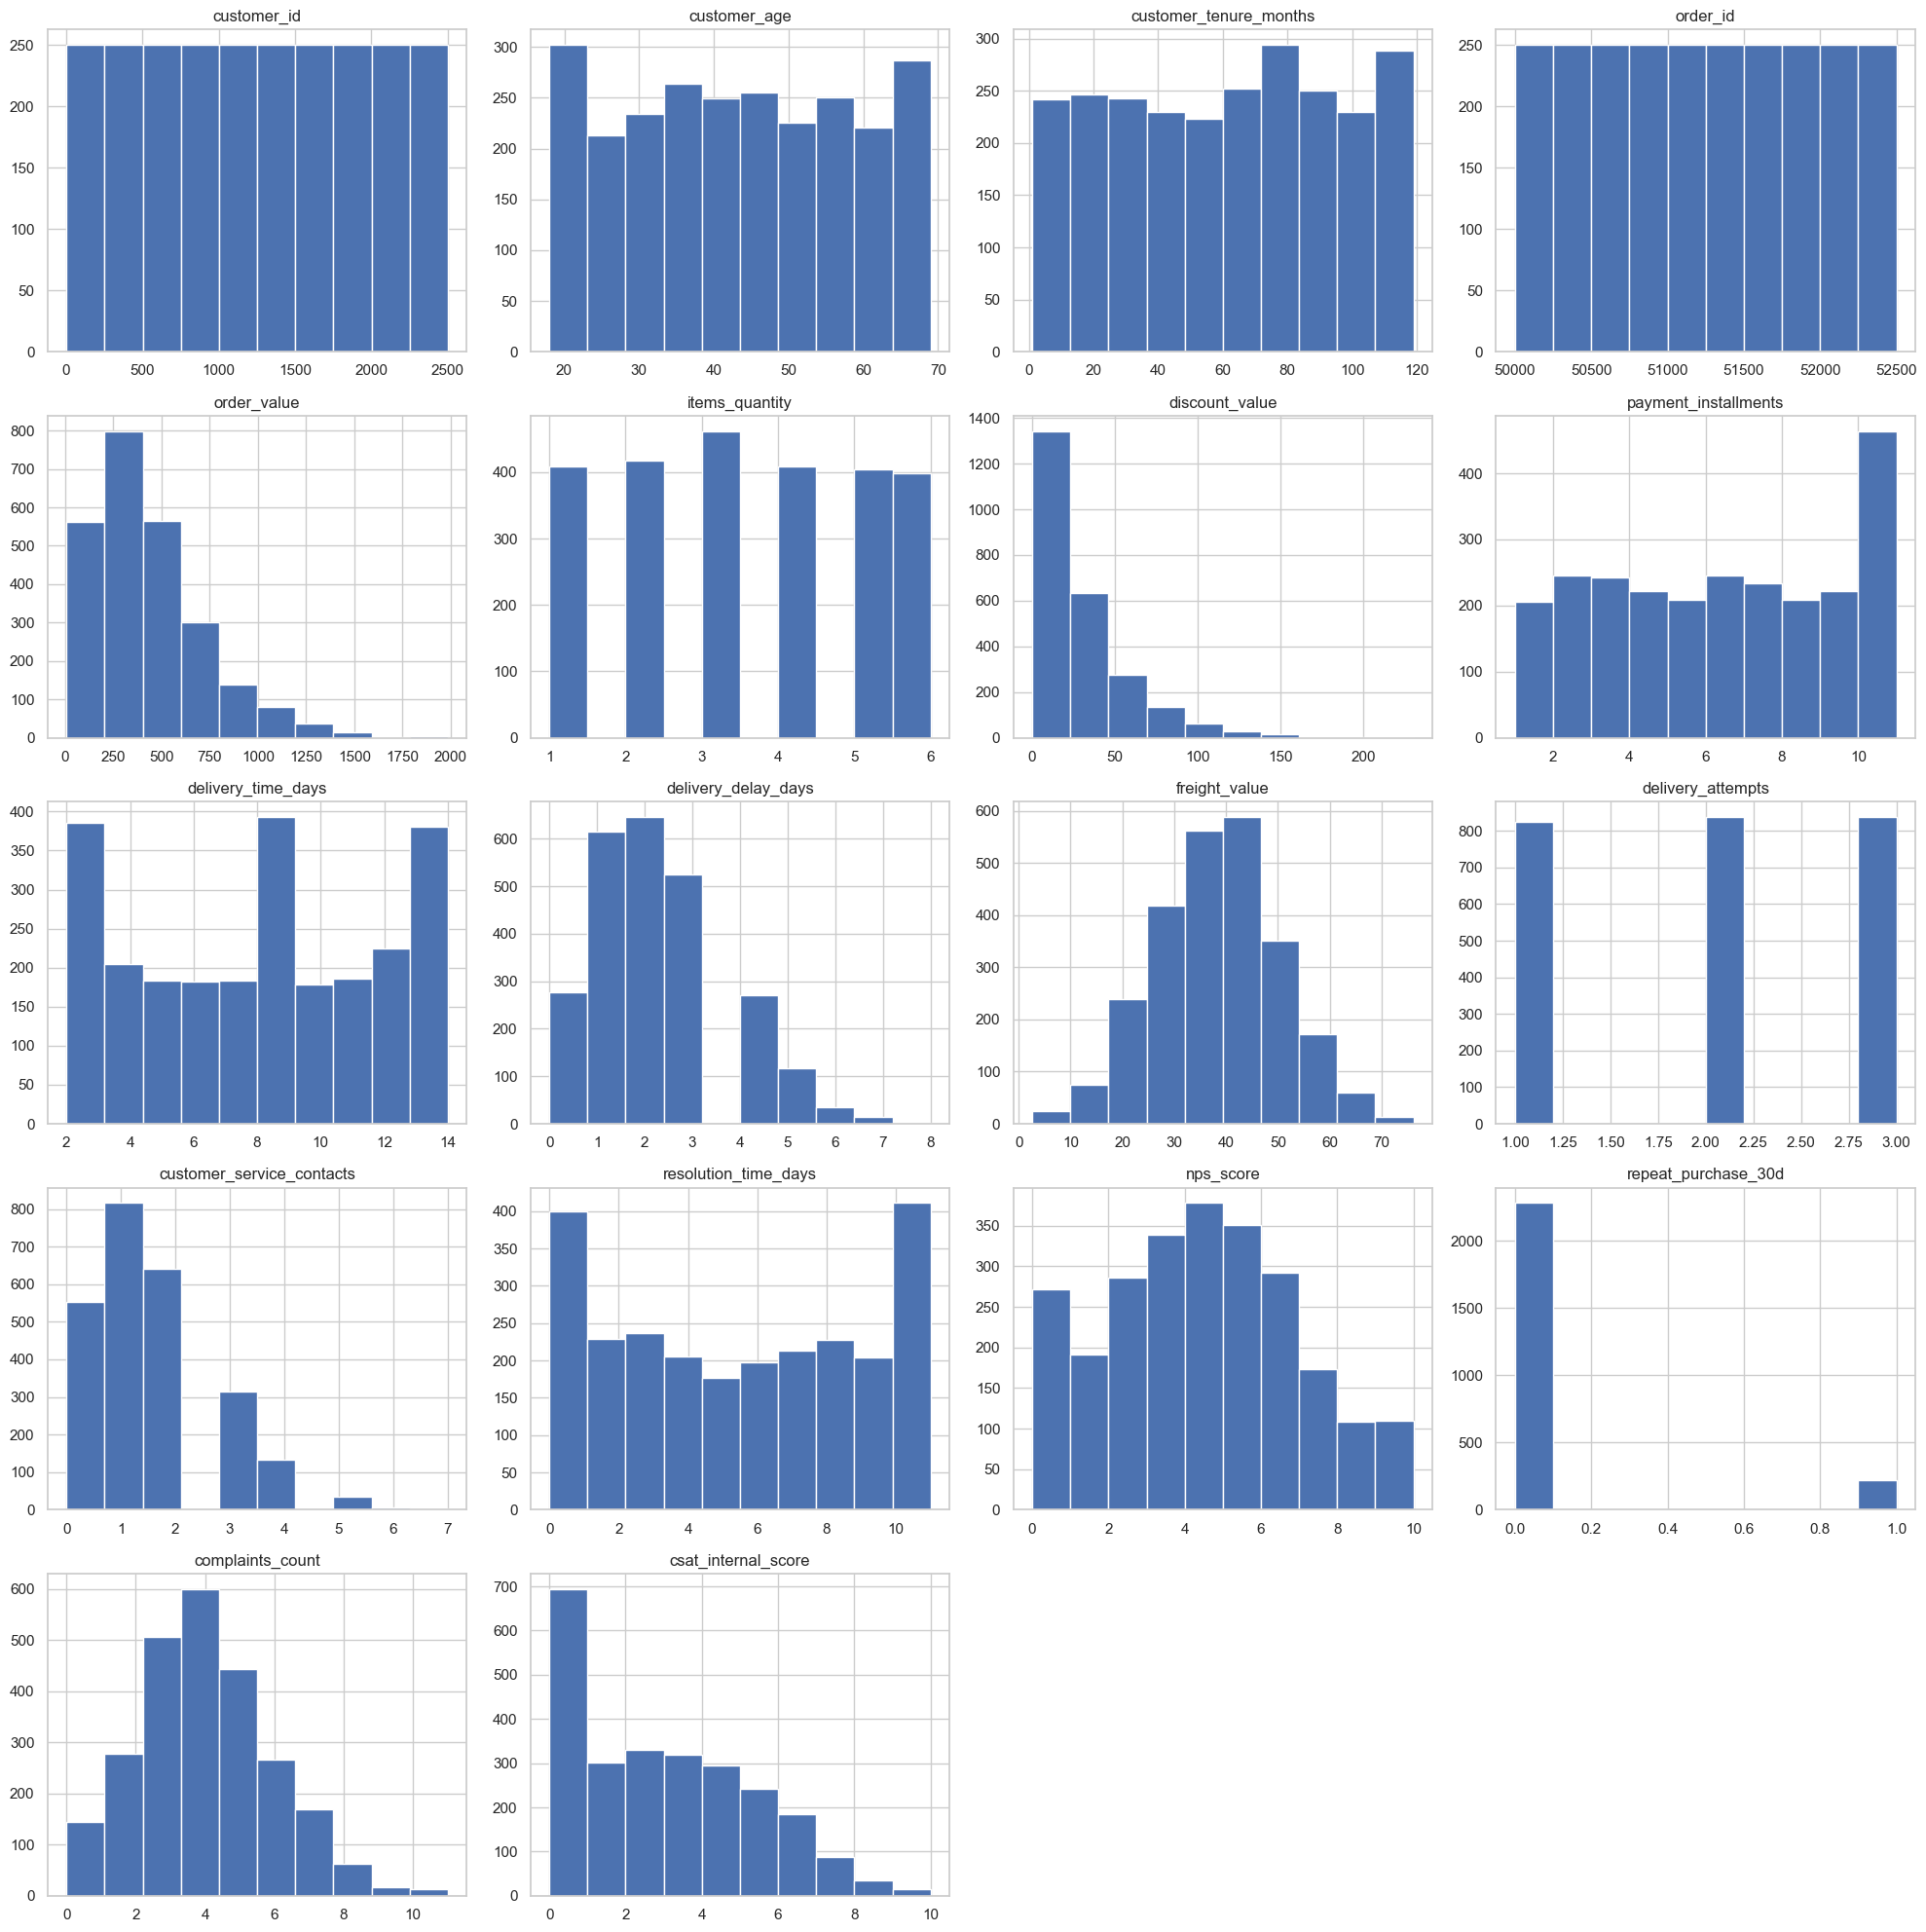

In [10]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(20,20))
plt.tight_layout()
plt.show()

<h3 style="color:#2E86C1;">
Perfil do cliente
</h3>

- **customer_age** apresenta distribuição relativamente uniforme entre aproximadamente 18 e 70 anos, indicando uma base de clientes diversa em termos etários  
- **customer_tenure_months** também está bem distribuído, sugerindo a presença tanto de clientes novos quanto recorrentes  

**Insight**: O perfil do cliente não parece ser o principal fator de diferenciação da experiência.

<h3 style="color:#2E86C1;">
Características do pedido
</h3>

- **order_value** apresenta forte assimetria à direita, com predominância de pedidos de baixo valor e poucos pedidos muito altos  
- **items_quantity** concentra-se entre 1 e 6 itens, indicando pedidos pequenos  
- **discount_value** é altamente concentrado em valores baixos, com poucos casos de descontos elevados  

**Insight**: A operação é baseada em pedidos de baixo ticket e baixa quantidade, característica de um e-commerce mais massificado.

<h3 style="color:#2E86C1;">
Pagamento
</h3>

- **payment_installments** apresenta uma distribuição relativamente espalhada, com aumento relevante na frequência de parcelas mais altas (acima de 10)  

**Insight**: Existe uma tendência de parte dos clientes optarem por parcelamentos mais longos.

Indícios de:

- sensibilidade a preço ou necessidade de diluir o pagamento  
- associação com pedidos de maior valor  
- possível impacto na percepção de valor e satisfação, dependendo das condições financeiras  

<h3 style="color:#2E86C1;">
Logística
</h3>

- **delivery_time_days** apresenta grande dispersão (2 a 14 dias), indicando inconsistência operacional  
- **delivery_delay_days** concentra-se entre 0 e 3 dias, mas com cauda longa até 8 dias  
- **freight_value** apresenta distribuição aproximadamente normal, centrada em valores médios  
- **delivery_attempts** concentra-se entre 1 e 3 tentativas  

**Insight crítico**: Existe alta variabilidade logística, principalmente em tempo e atraso de entrega.

Indícios de:

- falta de padronização  
- dependência de fatores externos  
- impacto direto na experiência do cliente  

<h3 style="color:#2E86C1;">
Atendimento ao cliente
</h3>

- **customer_service_contacts** concentra-se entre 0 e 2 contatos, mas com alguns casos extremos  
- **resolution_time_days** apresenta distribuição ampla (0 a 10 dias), indicando inconsistência na resolução  
- **complaints_count** concentra-se entre 2 e 6 reclamações  

**Insight crítico**: Existe uma parcela relevante de clientes com problemas recorrentes.

Indícios de:

- falhas ao longo da jornada  
- retrabalho  
- atendimento predominantemente reativo  

<h3 style="color:#2E86C1;">
Comportamento de recompra
</h3>

- **repeat_purchase_30d** é extremamente desbalanceada (quase todos = 0)  

**Insight crítico**: Baixa retenção de curto prazo.

Possível relação com:

- experiência inconsistente  
- ausência de mecanismos de fidelização  

<h3 style="color:#2E86C1;">
Satisfação
</h3>

- **nps_score** apresenta concentração na faixa intermediária (3 a 7), com presença relevante de detratores  
- **csat_internal_score** concentra-se em valores baixos a médios  

**Insight**: A própria métrica interna já sinaliza problemas na experiência do cliente.

<h3 style="color:#2E86C1;">
Insight geral
</h3>

A análise univariada revela um padrão consistente:

A operação apresenta alta variabilidade e inconsistência, principalmente em:

- logística (tempo e atraso)  
- atendimento (tempo de resolução)  
- experiência (distribuição do NPS)  

<h3 style="color:#2E86C1;">
Hipóteses geradas
</h3>

O problema não parece ser pontual. Há indícios de um problema estrutural de consistência operacional.

Principais hipóteses:

1. Atrasos na entrega impactam negativamente o NPS  
2. Tempo de resolução elevado reduz a satisfação  
3. Clientes com múltiplos contatos tendem a ser detratores  
4. Reclamações estão diretamente associadas à experiência negativa  
5. Baixa recompra está relacionada a experiências ruins  
6. Clientes com maior número de parcelas podem apresentar comportamento diferente em relação ao NPS, seja por maior comprometimento financeiro ou expectativa mais alta  

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
6. Análise bivariada (drivers do NPS)
</h2>

Depois de entender o comportamento individual das variáveis, o próximo passo é analisar como elas se relacionam com o NPS.

O objetivo desta etapa é identificar possíveis drivers da satisfação, avaliando quais fatores operacionais parecem ter maior impacto na experiência do cliente.

Nesta análise, o foco será:

- comparar o NPS em diferentes faixas de variáveis operacionais  
- identificar padrões de aumento ou queda na satisfação  
- validar as hipóteses levantadas na análise univariada  

Mais do que encontrar correlações, a ideia é entender quais variáveis fazem sentido, do ponto de vista de negócio, como possíveis alavancas de melhoria.

### `delivery_delay_days`

<Axes: xlabel='delivery_delay_days', ylabel='nps_score'>

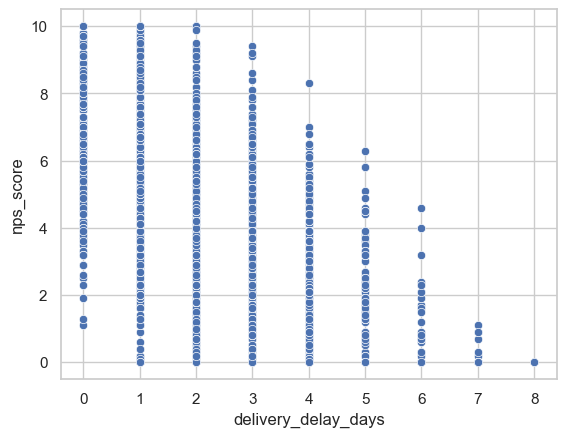

In [11]:
sns.scatterplot(
    x="delivery_delay_days",
    y="nps_score",
    data=df
)

<h3 style="color:#2E86C1;">
Atraso na entrega vs NPS
</h3>

A relação entre o número de dias de atraso na entrega (`delivery_delay_days`) e o NPS revela um padrão claro de deterioração da satisfação do cliente.

<h3 style="color:#2E86C1;">
Observações
</h3>

- para atrasos baixos (0 a 2 dias), o NPS apresenta alta variabilidade, incluindo tanto clientes satisfeitos quanto insatisfeitos  
- à medida que o atraso aumenta (3 a 5 dias), observa-se uma redução progressiva das notas mais altas  
- para atrasos maiores (acima de 5 dias), há concentração crescente de notas baixas, com poucos ou nenhum cliente altamente satisfeito  
- em níveis extremos de atraso (7+ dias), o NPS tende a se concentrar próximo de 0  

<h3 style="color:#2E86C1;">
Insight
</h3>

Existe uma relação negativa clara entre atraso na entrega e satisfação do cliente.

- pequenos atrasos ainda podem ser tolerados  
- a partir de aproximadamente 3–4 dias, o impacto na experiência se torna significativo  
- atrasos elevados praticamente eliminam a chance de o cliente se tornar promotor  

<h3 style="color:#2E86C1;">
Hipótese validada
</h3>

O atraso na entrega se confirma como um dos principais drivers de insatisfação do cliente.

<h3 style="color:#2E86C1;">
Implicação prática
</h3>

- reduzir atrasos tende a gerar impacto direto no aumento do NPS  
- controlar casos de atraso extremo deve ser uma prioridade operacional  
- a logística se confirma como um dos pontos mais críticos da jornada do cliente  

<Axes: xlabel='delivery_delay_days', ylabel='nps_score'>

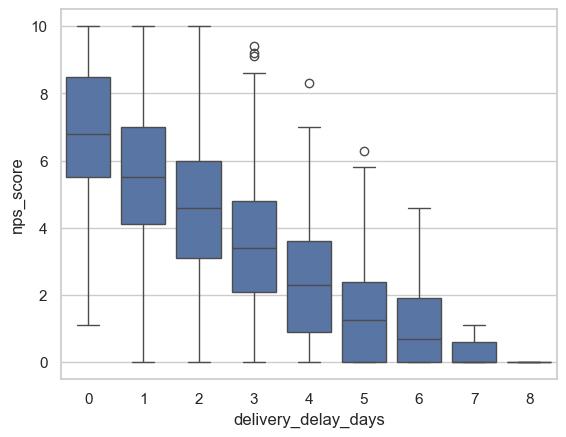

In [12]:
sns.boxplot(
    x="delivery_delay_days",
    y="nps_score",
    data=df
)

### `customer_service_contacts`

<Axes: xlabel='customer_service_contacts', ylabel='nps_score'>

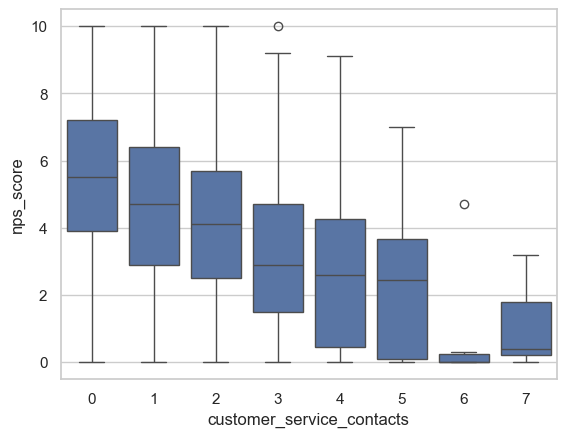

In [14]:
sns.boxplot(
    x="customer_service_contacts",
    y="nps_score",
    data=df
)

<h3 style="color:#2E86C1;">
Número de contatos com atendimento vs NPS
</h3>

A relação entre o número de contatos com o atendimento ao cliente (`customer_service_contacts`) e o NPS revela um padrão claro de deterioração da experiência conforme aumenta a necessidade de suporte.

<h3 style="color:#2E86C1;">
Observações
</h3>

- clientes com **0 contatos** apresentam, em média, NPS mais alto, com maior presença de notas elevadas  
- à medida que o número de contatos aumenta (1–3), observa-se uma queda progressiva na mediana do NPS  
- para níveis mais altos de contato (4+), o NPS passa a se concentrar majoritariamente em valores baixos  
- em casos extremos (6–7 contatos), praticamente não há clientes satisfeitos  

<h3 style="color:#2E86C1;">
Insight
</h3>

Existe uma relação negativa forte entre número de contatos com atendimento e satisfação do cliente.

- a necessidade de contato com atendimento é um forte indicativo de falhas na jornada  
- clientes que precisam interagir várias vezes com o suporte tendem a ter experiências mais frustrantes  
- o atendimento parece atuar de forma predominantemente **reativa**, e não preventiva  

<h3 style="color:#2E86C1;">
Hipótese validada
</h3>

Quanto maior o número de interações com o atendimento, menor tende a ser o NPS.

<h3 style="color:#2E86C1;">
Implicação prática
</h3>

- reduzir a necessidade de contato com atendimento tende a gerar impacto direto no NPS  
- melhorar a resolução no primeiro contato é um ponto crítico  
- atuar nas causas raiz dos contatos, como atraso ou erro no pedido, tende a ser mais efetivo do que melhorar apenas o atendimento em si  

<Axes: xlabel='customer_service_contacts', ylabel='nps_score'>

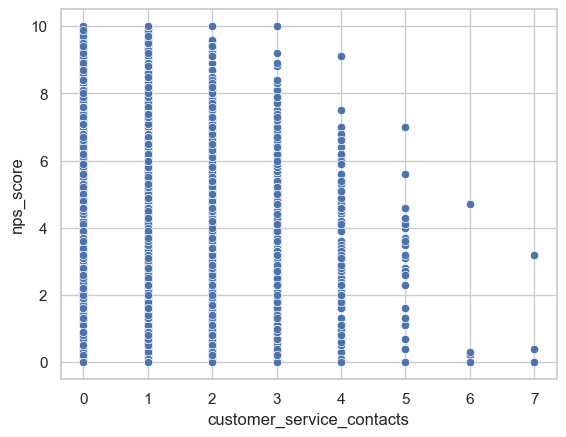

In [ ]:
sns.scatterplot(
    x="customer_service_contacts",
    y="nps_score",
    data=df
)

<h3 style="color:#2E86C1;">
Análise complementar (Scatter)
</h3>

A visualização em scatter complementa a análise anterior ao evidenciar a dispersão dos dados.

Observa-se que:

- mesmo com poucos contatos (0–2), há alta variabilidade no NPS, indicando que nem todo contato está associado a uma experiência negativa  
- a partir de aproximadamente 3 contatos, a frequência de notas altas começa a diminuir  
- em níveis mais elevados (5+ contatos), predominam avaliações baixas, com redução significativa de promotores  

<h3 style="color:#2E86C1;">
Insight
</h3>

O número de contatos não apenas reduz o NPS médio, mas também diminui a probabilidade de experiências altamente satisfatórias.

Isso sugere que, além de impactar a média, o atendimento afeta a consistência da experiência ao longo da base de clientes.

### `resolution_time_days`

<Axes: xlabel='resolution_time_days', ylabel='nps_score'>

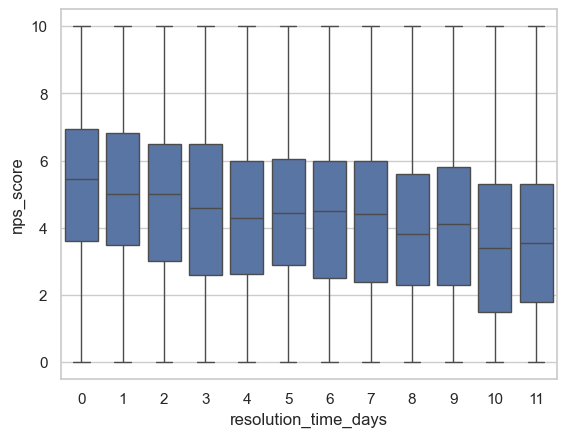

In [15]:
sns.boxplot(
    x="resolution_time_days",
    y="nps_score",
    data=df
)

<h3 style="color:#2E86C1;">
Tempo de resolução vs NPS
</h3>

A relação entre o tempo de resolução de problemas (`resolution_time_days`) e o NPS evidencia o impacto da eficiência do atendimento na experiência do cliente.

<h3 style="color:#2E86C1;">
Observações
</h3>

- para tempos de resolução baixos (0–2 dias), o NPS apresenta valores mais altos, com maior presença de clientes satisfeitos  
- à medida que o tempo de resolução aumenta, observa-se uma redução gradual na mediana do NPS  
- para tempos mais elevados (acima de 7–8 dias), há maior concentração de avaliações baixas  
- o efeito não é abrupto, mas consistente ao longo do aumento do tempo  

<h3 style="color:#2E86C1;">
Insight
</h3>

Existe uma relação negativa entre tempo de resolução e satisfação do cliente.

- a rapidez na resolução de problemas é um fator relevante para a percepção de qualidade do atendimento  
- problemas que demoram a ser resolvidos tendem a gerar frustração e impactar negativamente a experiência  
- diferente do número de contatos, o impacto aqui é mais gradual e cumulativo  

<h3 style="color:#2E86C1;">
Hipótese validada
</h3>

Quanto maior o tempo de resolução, menor tende a ser o NPS.

<h3 style="color:#2E86C1;">
Implicação prática
</h3>

- reduzir o tempo de resolução tende a melhorar a satisfação do cliente  
- otimizar processos internos e fluxos de atendimento pode gerar impacto direto no NPS  
- a eficiência do atendimento é tão relevante quanto sua própria disponibilidade  

### `complaints_count`

<Axes: xlabel='complaints_count', ylabel='nps_score'>

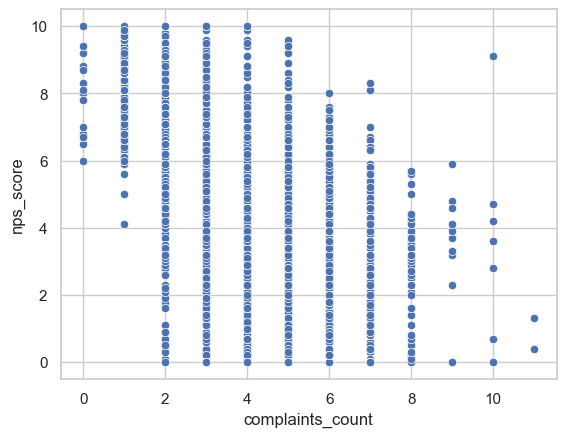

In [ ]:
sns.scatterplot(
    x="complaints_count",
    y="nps_score",
    data=df
)

<h3 style="color:#2E86C1;">
Número de reclamações vs NPS
</h3>

A relação entre o número de reclamações registradas (`complaints_count`) e o NPS evidencia um padrão consistente de deterioração da satisfação do cliente à medida que aumentam os problemas ao longo da jornada.

<h3 style="color:#2E86C1;">
Observações
</h3>

- clientes com **0 reclamações** apresentam NPS predominantemente alto, com concentração em notas entre 8 e 10  
- para níveis baixos a moderados de reclamações (1 a 4), observa-se maior dispersão no NPS, incluindo tanto avaliações altas quanto baixas  
- à medida que o número de reclamações aumenta (5 a 7), há redução progressiva na frequência de notas elevadas  
- em níveis mais altos (8+ reclamações), o NPS passa a se concentrar em valores baixos, com poucos ou nenhum cliente altamente satisfeito  

<h3 style="color:#2E86C1;">
Insight
</h3>

Existe uma relação negativa clara entre número de reclamações e satisfação do cliente.

O impacto não está apenas na média do NPS, mas também na probabilidade de experiências positivas, que diminui significativamente conforme aumentam os problemas.

- reclamações são um forte indicativo de falhas ao longo da jornada  
- clientes com múltiplas reclamações tendem a acumular frustração  
- existe uma faixa intermediária (aproximadamente 2 a 5 reclamações) em que a experiência ainda pode ser recuperada  
- a partir de determinado nível, a probabilidade de satisfação elevada se torna muito baixa  

<h3 style="color:#2E86C1;">
Hipótese validada
</h3>

O número de reclamações se confirma como um dos principais drivers de insatisfação do cliente.

<h3 style="color:#2E86C1;">
Implicação prática
</h3>

- reduzir a ocorrência de problemas ao longo da jornada é essencial para melhorar o NPS  
- clientes com múltiplas reclamações devem ser tratados como casos prioritários  
- identificar precocemente o aumento no número de reclamações permite ações preventivas  
- melhorar a resolução dos problemas pode mitigar parcialmente o impacto negativo, principalmente nos estágios intermediários  

<Axes: xlabel='complaints_count', ylabel='nps_score'>

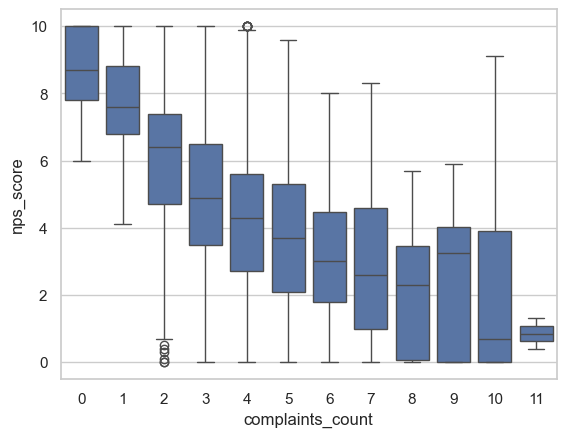

In [21]:
sns.boxplot(
    x="complaints_count",
    y="nps_score",
    data=df
)

<h3 style="color:#2E86C1;">
Análise complementar (Boxplot)
</h3>

O boxplot evidencia de forma clara a relação entre o número de reclamações e o NPS, mostrando não apenas a tendência central, mas também a dispersão das avaliações em cada nível.

<h3 style="color:#2E86C1;">
Observações
</h3>

- clientes com **0 reclamações** apresentam NPS elevado, com mediana próxima de 9, indicando alta satisfação  
- à medida que o número de reclamações aumenta, observa-se uma **queda progressiva da mediana do NPS**  
- para valores intermediários (2 a 5 reclamações), há maior dispersão, indicando experiências mais heterogêneas  
- a partir de níveis mais altos (7+ reclamações), o NPS se concentra em valores baixos, com predominância de detratores  
- em casos extremos (10+ reclamações), a mediana do NPS é próxima de zero, indicando forte insatisfação  

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
7. Correlação
</h2>

Depois das análises univariada e bivariada, a análise de correlação ajuda a quantificar a relação entre as variáveis e o NPS.

O objetivo desta etapa é:

- identificar quais variáveis têm maior associação com o `nps_score`  
- comparar a intensidade dessas relações  
- validar, de forma quantitativa, os padrões observados anteriormente  

É importante destacar que correlação não implica causalidade. Ainda assim, ela funciona como um bom indicativo inicial de quais variáveis podem atuar como drivers da satisfação do cliente.

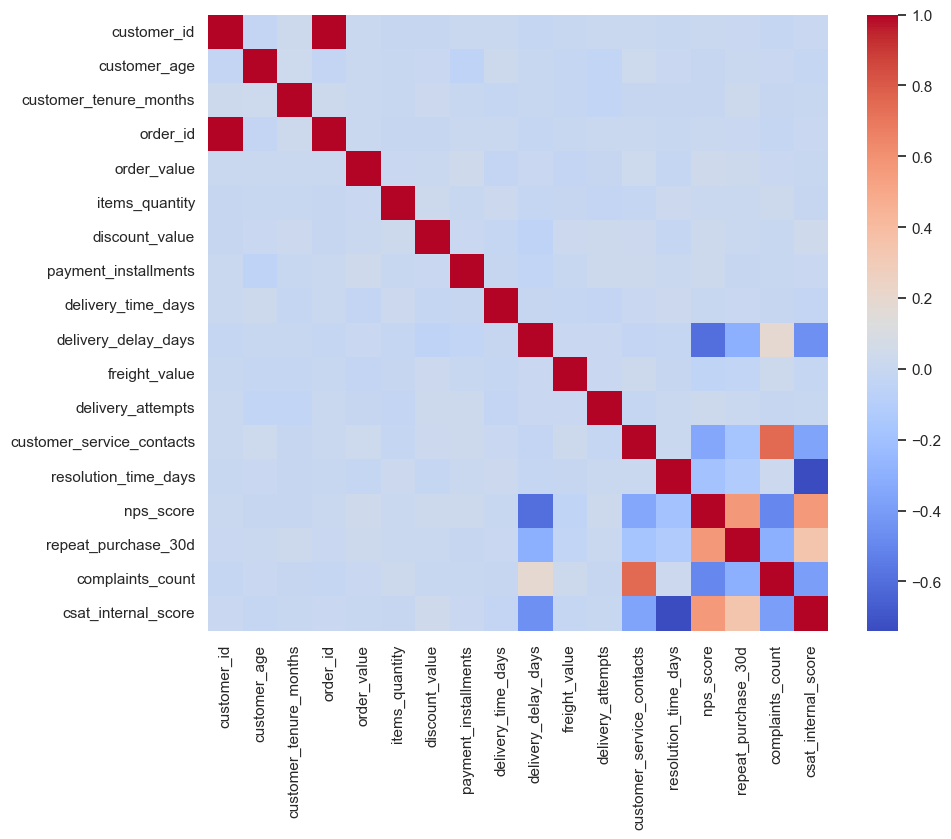

In [17]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [18]:
corr['nps_score'].sort_values()

delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
freight_value               -0.041087
customer_age                -0.009936
customer_tenure_months      -0.009711
delivery_time_days           0.000925
items_quantity               0.011468
customer_id                  0.015162
order_id                     0.015162
payment_installments         0.023718
discount_value               0.025104
delivery_attempts            0.027680
order_value                  0.036990
csat_internal_score          0.563952
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64

A matriz de correlação permite identificar relações lineares entre as variáveis, ajudando a entender possíveis drivers do NPS e também a detectar redundâncias entre features.

<h3 style="color:#2E86C1;">
Observações gerais
</h3>

- a maioria das variáveis apresenta **baixa correlação entre si**, indicando que capturam aspectos diferentes da jornada do cliente  
- isso é positivo, pois reduz problemas de multicolinearidade e sugere que cada variável contribui com informação complementar  

<h3 style="color:#2E86C1;">
Relações mais relevantes com o NPS
</h3>

#### Correlações negativas

- **delivery_delay_days**  
- **customer_service_contacts**  
- **resolution_time_days**  
- **complaints_count**  

**Insight**: Variáveis relacionadas a problemas operacionais e fricção na jornada apresentam correlação negativa com o NPS.

Isso reforça as análises bivariadas anteriores:

- mais atraso → menor NPS  
- mais contatos → menor NPS  
- mais reclamações → menor NPS  

#### Correlações positivas

- **repeat_purchase_30d**  
- **csat_internal_score**  

**Insight**: Clientes mais satisfeitos tendem a recomprar e apresentam melhor avaliação interna.

Uma conexão importante aparece aqui:

- NPS (percepção)  
- recompra (comportamento)  

<h3 style="color:#2E86C1;">
Relações entre variáveis explicativas
</h3>

Observam-se correlações relevantes entre:

- **customer_service_contacts ↔ complaints_count**  
- **complaints_count ↔ resolution_time_days**  
- **delivery_delay_days ↔ complaints_count**  

**Insight**: As variáveis operacionais estão interligadas e representam diferentes etapas de um mesmo problema ao longo da jornada.

<h3 style="color:#2E86C1;">
Síntese
</h3>

A análise de correlação reforça que:

- a insatisfação do cliente está fortemente associada a **falhas operacionais**  
- existe um efeito em cadeia ao longo da jornada:

```text
atraso → contato → reclamação → demora na resolução → queda no NPS

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
8. Teste de hipótese
</h2>

Para validar, de forma estatística, os padrões observados na análise exploratória, será realizado um teste de hipótese.

O objetivo é verificar se o atraso na entrega tem impacto significativo no NPS.

<h3 style="color:#2E86C1;">
Definição das hipóteses: atraso na entrega
</h3>

- **H0 (hipótese nula):** o atraso na entrega não afeta o NPS  
- **H1 (hipótese alternativa):** o atraso na entrega afeta o NPS  

In [26]:
from scipy.stats import kruskal

groups = [
    df[df['delivery_delay_days'] == i]['nps_score']
    for i in df['delivery_delay_days'].unique()
]

stat, p_value = kruskal(*groups)

print(f'p-value: {p_value}')
if p_value < 0.05:
    print('Rejeita-se H0 --> Atraso impacta o NPS')
else:
    print('O atraso não afeta o NPS')

p-value: 8.769910061341424e-185
Rejeita-se H0 --> Atraso impacta o NPS


<h3 style="color:#2E86C1;">
Definição das hipóteses: contatos com atendimento
</h3>

- **H0 (hipótese nula):** o número de contatos com atendimento não afeta o NPS 
- **H1 (hipótese alternativa):** o número de contatos com atendimento afeta o NPS

In [29]:
groups = [
    df[df['customer_service_contacts'] == i]['nps_score']
    for i in df['customer_service_contacts'].unique()
]

stat, p_value = kruskal(*groups)

print(f'p-value: {p_value}')
if p_value < 0.05:
    print('Rejeita-se H0 --> Contatos impactam o NPS')
else:
    print('Contatos não afetam o NPS')

p-value: 3.4436648557795536e-61
Rejeita-se H0 --> Contatos impactam o NPS


<h3 style="color:#2E86C1;">
Definição das hipóteses: reclamações
</h3>

- **H0 (hipótese nula):** o número de reclamações não afeta o NPS
- **H1 (hipótese alternativa):** o número de reclamações afeta o NPS

In [30]:
groups = [
    df[df['complaints_count'] == i]['nps_score']
    for i in df['complaints_count'].unique()
]

stat, p_value = kruskal(*groups)

print(f'p-value: {p_value}')
if p_value < 0.05:
    print('Rejeita-se H0 --> Reclamações impactam o NPS')
else:
    print('Reclamações não afetam o NPS')

p-value: 1.1786250649323183e-135
Rejeita-se H0 --> Reclamações impactam o NPS


Para validar, de forma estatística, os padrões observados na análise exploratória, foram realizados testes de hipótese utilizando o teste de Kruskal-Wallis, adequado para comparar distribuições entre múltiplos grupos sem assumir normalidade.

<h3 style="color:#2E86C1;">
Resultados
</h3>

- para `delivery_delay_days`, o p-value foi inferior a 0.05, indicando diferença estatisticamente significativa na distribuição do NPS entre os grupos  
- para `customer_service_contacts`, também foi observada significância estatística  
- para `complaints_count`, o resultado reforça a relação com o NPS, com diferenças relevantes entre os níveis da variável  

<h3 style="color:#2E86C1;">
Conclusão
</h3>

Os testes indicam que é possível rejeitar a hipótese nula (H0) para as variáveis analisadas, sugerindo que fatores operacionais têm impacto estatisticamente significativo sobre o NPS.

Esses resultados reforçam, de forma quantitativa, os insights obtidos na análise exploratória e mostram que atraso na entrega, interações com atendimento e número de reclamações são drivers relevantes da satisfação do cliente.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
9. Principais insights
</h2>

A análise exploratória permitiu identificar padrões consistentes sobre os fatores que influenciam a satisfação do cliente (NPS).

<h3 style="color:#2E86C1;">
1. A satisfação do cliente é fortemente influenciada por fatores operacionais
</h3>

As variáveis com maior impacto no NPS estão relacionadas à execução da jornada, especialmente:

- atraso na entrega (`delivery_delay_days`)  
- número de contatos com atendimento (`customer_service_contacts`)  
- número de reclamações (`complaints_count`)  
- tempo de resolução (`resolution_time_days`)  

**Insight**: O NPS é predominantemente determinado pela qualidade da operação, e não pelo perfil do cliente.

<h3 style="color:#2E86C1;">
2. Existe um efeito acumulativo de fricções na jornada
</h3>

A insatisfação não surge de um único evento isolado, mas do acúmulo de problemas ao longo da experiência:

- mais atraso → mais contato  
- mais contato → mais reclamações  
- mais reclamações → menor NPS  

**Insight**: A deterioração da experiência é progressiva e cumulativa.

<h3 style="color:#2E86C1;">
3. Identificação de pontos de ruptura na experiência
</h3>

Algumas variáveis apresentam limiares a partir dos quais o impacto no NPS se intensifica:

- atraso acima de ~3–4 dias  
- mais de 3 contatos com atendimento  
- múltiplas reclamações (3+)  

**Insight**: Existem pontos críticos onde a experiência deixa de ser recuperável.

<h3 style="color:#2E86C1;">
4. Atendimento atua como fator moderador da experiência
</h3>

A análise mostrou que:

- mesmo diante de problemas, alguns clientes mantêm NPS mais alto  
- especialmente em níveis intermediários de fricção  

**Insight**: A qualidade da resolução pode mitigar parcialmente o impacto de falhas operacionais.

<h3 style="color:#2E86C1;">
5. Relação entre satisfação e comportamento de recompra
</h3>

- `repeat_purchase_30d` apresenta correlação positiva com o NPS  

**Insight**: Clientes mais satisfeitos têm maior probabilidade de recompra.

<h3 style="color:#2E86C1;">
6. Inconsistência operacional como problema central
</h3>

- alta dispersão no NPS  
- grande variabilidade em tempo de entrega e resolução  

**Insight**: A experiência do cliente não segue um padrão consistente.

<h3 style="color:#2E86C1;">
7. Perfil do cliente tem baixo impacto na satisfação
</h3>

Variáveis como idade e tempo de relacionamento não apresentaram relação relevante com o NPS.

**Insight**: O problema não está no perfil do cliente, mas na execução da operação.

<h2 style="color:#2E86C1; border-bottom: 2px solid #2E86C1; padding-bottom: 5px;">
10. Conclusão
</h2>

A análise exploratória indica que a satisfação do cliente, medida pelo NPS, é fortemente influenciada por fatores operacionais ao longo da jornada de compra.

Os resultados mostram que a insatisfação não está associada a um único evento, mas ao acúmulo de fricções, principalmente em logística e atendimento. Variáveis como atraso na entrega, número de contatos, volume de reclamações e tempo de resolução apresentam impacto consistente e estatisticamente significativo sobre o NPS.

A análise também evidencia a existência de pontos críticos na experiência, a partir dos quais a probabilidade de satisfação elevada diminui de forma relevante. Ao mesmo tempo, observa-se que a qualidade da resolução pode mitigar parcialmente esses efeitos, reforçando o papel do atendimento na recuperação da experiência.

Outro ponto importante é a relação entre satisfação e comportamento. Clientes com maior NPS apresentam maior probabilidade de recompra, indicando impacto direto na retenção.

De forma geral, os resultados sugerem que o principal desafio da empresa não está no perfil dos clientes, mas na consistência operacional da jornada. Melhorias na execução, especialmente em logística e atendimento, têm potencial direto de aumentar a satisfação e gerar impacto positivo no negócio.

<h3 style="color:#2E86C1;">
Recomendações
</h3>

- priorizar clientes com 3+ reclamações como casos críticos  
- monitorar e atuar rapidamente em atrasos acima de 3 dias  
- implementar ações preventivas para evitar o acúmulo de fricções ao longo da jornada  

<h3 style="color:#2E86C1;">
Limitações
</h3>

- possível ausência de variáveis relevantes não observadas  
- relações identificadas não implicam causalidade  
- resultados dependem da qualidade e representatividade da base  
- possível desbalanceamento em algumas variáveis  